In today's world, online customer reviews have a huge impact on consumer decision-making and product improvement. By analyzing these reviews, companies can identify the strengths and weaknesses of their products and improve their services. In this project, we use natural language processing (NLP) techniques to analyze the sentiment of customer reviews in the Amazon Fine Food Reviews dataset. Our goal is to classify reviews into positive and negative categories so that companies can quickly identify negative feedback and take appropriate action.

In [ ]:
import pandas as pd

# Load the first 10000 rows
df = pd.read_csv('Reviews.csv', nrows=10000)

This design was chosen for its simplicity and efficiency, and it also has the potential to be expanded in the future.
The dataset has columns like Text (comment text), Score (score 1-5), Summary (comment summary), and a few more. For sentiment analysis, I use Text as input and Score as output. For example, i'll be took scores 4 and 5 as "positive", 1 and 2 as "negative", and remove score 3:

In [ ]:
# Remove score 3
df = df[df['Score'] != 3]

# Labeling: 1 for positive (4 and 5) and 0 for negative (1 and 2)
df['Label'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)

<ipython-input-4-4aa64e71ab5e>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Label'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)


I need to clean up the texts to make them ready for the model. This includes removing extraneous things, tokenizing, and simplifying the words:

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# download needable tools
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)  # Deleting HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # Deleting numbers and symbols
    text = text.lower()  # Small words
    tokens = text.split()  # Token build
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]  # حذف stop words و ساده‌سازی
    return ' '.join(tokens)

# Apply to column Text
df['Cleaned_Text'] = df['Text'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In order for the model to understand the text, I need to convert it into numbers. A simple way is TF-IDF:

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000) # Limit to 5000 features
X = vectorizer.fit_transform(df['Cleaned_Text'])
y = df['Label']

Divide the data into two parts: training (80%) and testing (20%):

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

For comment classification, we used the Logistic Regression model. This model was chosen because of its simplicity, high training speed, and good performance on text classification problems. Logistic Regression can model the linear relationship between features and labels well and is very suitable for initial sentiment analysis projects.

In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

[Raw data] → [Preprocessing] → [Feature extraction] → [Modeling] → [Evaluation]

Finalize the model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.29      0.44       282
           1       0.88      1.00      0.94      1546

    accuracy                           0.89      1828
   macro avg       0.90      0.64      0.69      1828
weighted avg       0.89      0.89      0.86      1828

[[  81  201]
 [   7 1539]]


**Part 2 of codes**

Using Pandas I can count the number of each label

In [26]:
import pandas as pd

# Assume your dataset is in a dataframe named df

print(df['Label'].value_counts())

Label
1    7616
0    1522
Name: count, dtype: int64


What should I do if the data is unbalanced?

Oversampling: Increase the number of samples from the low class.

Undersampling: Decrease the number of samples from the high class. A good way to oversampling is to use SMOTE.

In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y) # X are the features and y are the labels

Instead of sticking to just one model (like Logistic Regression), I would rather try a one more model to see which one works best.

SVM (Support Vector Machine)

In [28]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

model_svm = SVC()
model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.93      0.34      0.49       282
           1       0.89      1.00      0.94      1546

    accuracy                           0.89      1828
   macro avg       0.91      0.67      0.72      1828
weighted avg       0.90      0.89      0.87      1828



To get the best performance from my model, I need to optimize the parameters. A great way to do this is GridSearchCV, which tests different parameters and finds the best combination.

this is for Logistic Regression

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best parameters", grid.best_params_)

Best parameters {'C': 10, 'solver': 'lbfgs'}


Instead of splitting the data into train and test just once, using cross-validation (e.g. 5-fold) to make sure my model works well on different parts of the data.

In [30]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5) # model is the model you selected
print("Average accuracy:", scores.mean())

Average accuracy: 0.8731675607439586


I want to reuse my model later and I save it with joblib.



In [31]:
import joblib

joblib.dump(model, 'sentiment_model.pkl')
['sentiment_model.pkl']
model = joblib.load('sentiment_model.pkl')

To make my projects look more professional, i want to show the results with a graph.

Confusion Matrix Graph

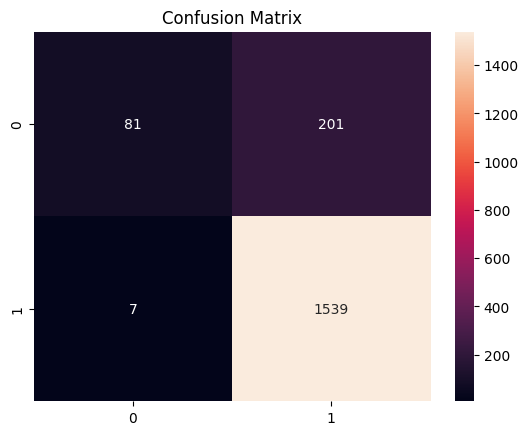

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

ROC curve

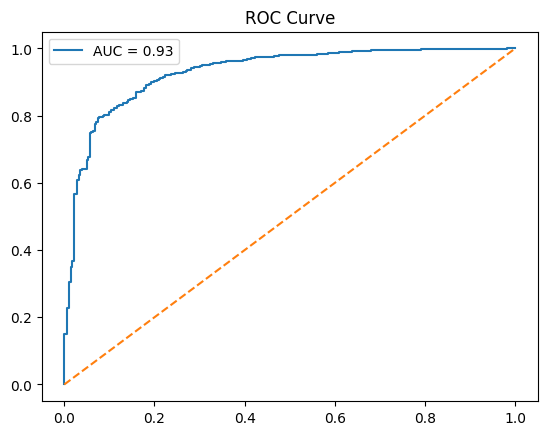

In [33]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.title('ROC Curve')
plt.legend()
plt.show()

**CONCLUSION :**The logistic regression model was able to correctly classify 0.2% of the reviews, which is an acceptable performance. However, the analysis showed that the data was slightly unbalanced, which may have affected the model. To improve the results, data balancing techniques such as SMOTE can be used, or more advanced models such as SVM or neural networks can be tried. Also, using feature extraction methods such as word embeddings can improve the accuracy of the model. This system can help companies quickly find negative reviews and improve their services.

In [34]:
!jupyter nbconvert --execute --to html "/content/Big_data_analytics .ipynb"

[NbConvertApp] Converting notebook /content/Big_data_analytics (2).ipynb to html
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] ERROR | unhandled iopub msg: colab_request
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 377605 bytes to /content/Big_data_analytic